<a href="https://colab.research.google.com/github/Bassendiaye/mes_notebooks/blob/main/VGG19_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import random
import numpy as np
from uuid import uuid4
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

In [ ]:
import matplotlib.pyplot as plt

# 1. Analyse et visualisation de la distribution des classes
def plot_class_distribution(data_dir):
  # Dictionnaire pour stocker le nombre d'images par classe
  repartition = {}

  # Extensions d'images
  extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

  # Comptage des images
  for nom_classe in os.listdir(data_dir):
      chemin_classe = os.path.join(data_dir, nom_classe)
      if os.path.isdir(chemin_classe):
          nb_images = len([f for f in os.listdir(chemin_classe) if f.lower().endswith(extensions)])
          repartition[nom_classe] = nb_images

  # Calcul des pourcentages
  total_images = sum(repartition.values())
  repartition_pourcentages = {classe: (nb / total_images) * 100 for classe, nb in repartition.items()}

  # -------- GRAPHE À BARRES --------
  plt.figure(figsize=(10, 6))
  bars = plt.bar(repartition.keys(), repartition.values(), color='skyblue')
  plt.xlabel("Classes")
  plt.ylabel("Nombre d'images")
  plt.title("Répartition des images par classe")
  plt.xticks(rotation=45)

  # Affichage des pourcentages au-dessus des barres
  for bar in bars:
      hauteur = bar.get_height()
      classe = bar.get_x() + bar.get_width() / 2
      pourcentage = (hauteur / total_images) * 100
      plt.text(classe, hauteur + 1, f"{pourcentage:.1f}%", ha='center', va='bottom', fontsize=10, color='black')

  plt.tight_layout()
  plt.show()
  return repartition

In [ ]:
def prepare_data_with_oversampling(data_dir, test_size=0.1, random_state=42, max_samples_per_class=4000):

    IMG_HEIGHT = 46
    IMG_WIDTH  = 322

    class_names = sorted([d for d in os.listdir(data_dir)
                          if os.path.isdir(os.path.join(data_dir, d))])

    file_paths, labels = [], []
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        class_files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        file_paths.extend(class_files)
        labels.extend([class_idx] * len(class_files))

    train_files, val_files, train_labels, val_labels = train_test_split(
        file_paths, labels, test_size=test_size,
        stratify=labels, random_state=random_state
    )

    def get_individual_transforms():
        return [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1),
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=1),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
            A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1),
            A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=1),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1),
            A.Defocus(radius=(3, 5), p=1),
            A.MotionBlur(blur_limit=(3, 5), p=1),
            A.GaussianBlur(blur_limit=(3, 5), p=1),
        ]

    def oversample(files, labels):
        label_to_files = defaultdict(list)
        for f, l in zip(files, labels):
            label_to_files[l].append(f)

        transforms = get_individual_transforms()

        base_transform = A.Compose([
            A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        AUG_DIR = os.path.join(os.path.dirname(data_dir), "split_4000_images_balanced")
        os.makedirs(AUG_DIR, exist_ok=True)

        oversampled_files, oversampled_labels = [], []

        for label, file_list in tqdm(label_to_files.items(), desc="Balancing classes"):
            n = len(file_list)

            if n >= max_samples_per_class:
                sampled = random.sample(file_list, max_samples_per_class)
                oversampled_files.extend(sampled)
                oversampled_labels.extend([label] * max_samples_per_class)

            else:
                oversampled_files.extend(file_list)
                oversampled_labels.extend([label] * n)

                needed = max_samples_per_class - n
                idx = 0

                while needed > 0:
                    img_path = file_list[idx % n]
                    image = cv2.imread(img_path)
                    if image is None:
                        idx += 1
                        continue
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                    for t in transforms:
                        if needed <= 0: break

                        composed = A.Compose([t, base_transform])
                        augmented = composed(image=image)
                        aug = augmented["image"]

                        aug_np = aug.permute(1, 2, 0).cpu().numpy()
                        aug_np = np.clip((aug_np * 0.5 + 0.5) * 255, 0, 255).astype("uint8")
                        aug_bgr = cv2.cvtColor(aug_np, cv2.COLOR_RGB2BGR)

                        new_path = os.path.join(AUG_DIR, f"{uuid4().hex}.jpg")
                        cv2.imwrite(new_path, aug_bgr)

                        oversampled_files.append(new_path)
                        oversampled_labels.append(label)
                        needed -= 1

                    idx += 1

        return oversampled_files, oversampled_labels

    train_files, train_labels = oversample(train_files, train_labels)

    return train_files, val_files, train_labels, val_labels, class_names

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, is_train=True):
        self.paths = image_paths
        self.labels = labels
        self.is_train = is_train

        self.train_transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
            ToTensorV2()
        ])

        self.val_transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label    = self.labels[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.is_train:
            image = self.train_transform(image=image)["image"]
        else:
            image = self.val_transform(image=image)["image"]

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
data_dir = "/content/drive/MyDrive/Dossier_de_Basse/Data_paper_TrainVal_Test/train_Val"

train_files, val_files, train_labels, val_labels, class_names = \
    prepare_data_with_oversampling(data_dir)

train_dataset = CustomImageDataset(train_files, train_labels, is_train=True)
val_dataset   = CustomImageDataset(val_files, val_labels, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))


/tmp/ipython-input-3075104761.py:29: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1),
Balancing classes: 100%|██████████| 8/8 [13:47<00:00, 103.41s/it]

Classes: ['AF', 'AFC', 'AFS', 'AFSC', 'FC', 'FS', 'FSC', 'NC']
Train size: 32000
Val size: 1543


Analyse de la distribution des classes...


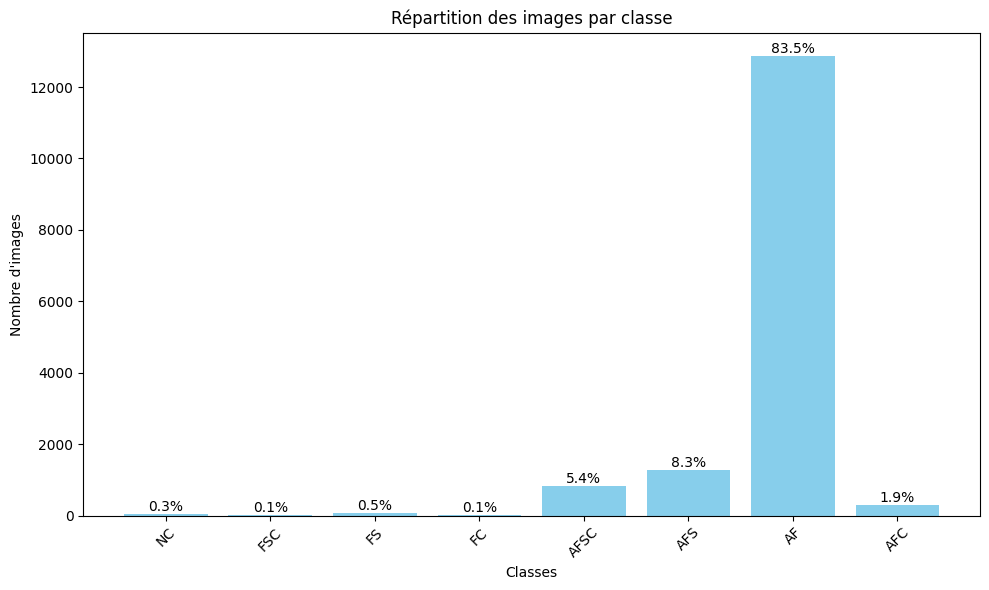

In [ ]:
print("Analyse de la distribution des classes...")
class_counts = plot_class_distribution(data_dir)

In [ ]:
# Afficher les distributions des labels (listes d'entiers)
def plot_label_distribution(labels, title):
    """Plots the distribution of labels in a list."""
    label_counts = Counter(labels)
    # Sort by label index for consistent plotting
    sorted_labels = sorted(label_counts.keys())
    sorted_counts = [label_counts[label] for label in sorted_labels]

    plt.figure(figsize=(12, 6))
    plt.bar([str(label) for label in sorted_labels], sorted_counts) # Convert labels to string for x-axis
    plt.title(title)
    plt.xlabel('Class Index')
    plt.ylabel('Number of samples')
    plt.xticks(rotation=45)
    plt.show()


Distribution des labels de train...


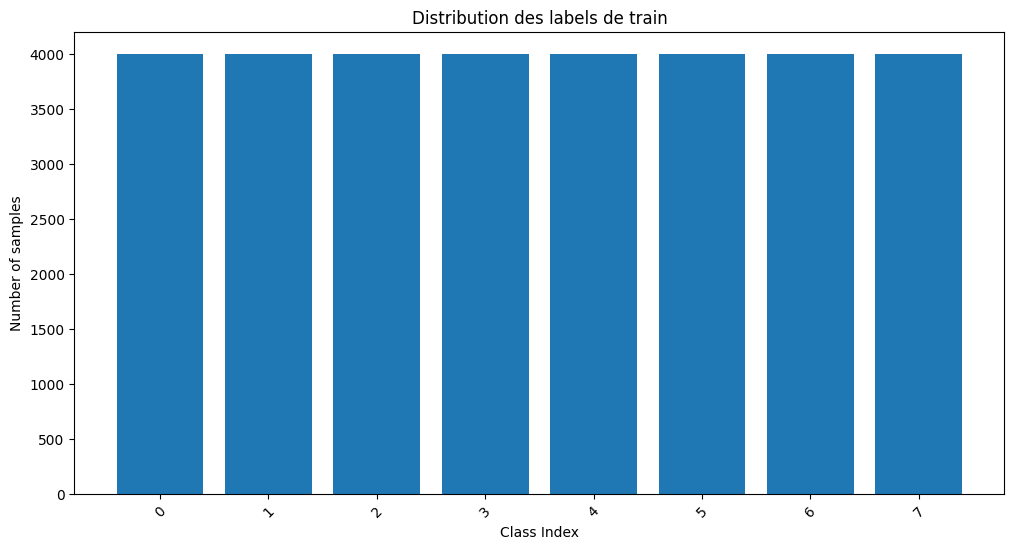

In [ ]:
from collections import Counter
print("\nDistribution des labels de train...")
plot_label_distribution(train_labels, 'Distribution des labels de train')


Distribution des labels de validation...


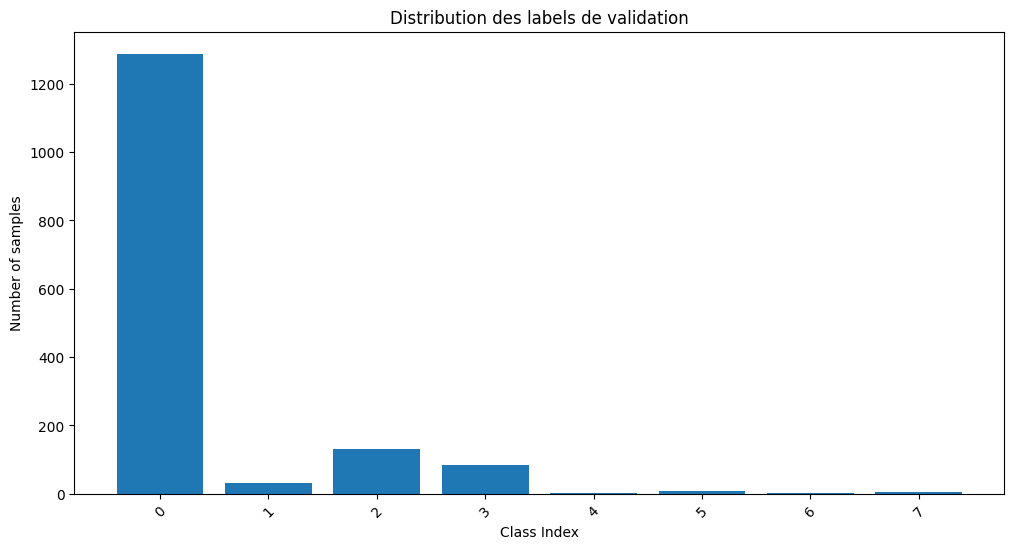

In [ ]:
print("\nDistribution des labels de validation...")
plot_label_distribution(val_labels, 'Distribution des labels de validation')

In [ ]:
num_classes = len(class_names)

vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
vgg19.classifier[6] = nn.Linear(4096, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg19 = vgg19.to(device)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 209MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg19.parameters(), lr=1e-4)

best_val_acc = 0

for epoch in range(100):

    # ------------------ TRAIN -------------------
    vgg19.train()
    correct = total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg19(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total * 100

    # ------------------ VALIDATION -------------------
    vgg19.eval()
    correct = total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = vgg19(imgs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total * 100

    print(f"Epoch {epoch+1}/100 - Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # ---------- Sauvegarde meilleur modèle ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vgg19.state_dict(), "/content/drive/MyDrive/Dossier_de_Basse/split_best_vgg19.pth")
        print(f" Meilleur modèle sauvegardé ! Avec best_val_acc = {best_val_acc: .2f}% ")

Epoch 1/100 - Train Acc: 87.90% | Val Acc: 95.20%
 Meilleur modèle sauvegardé ! Avec best_val_acc =  95.20% 
Epoch 2/100 - Train Acc: 96.03% | Val Acc: 93.97%
Epoch 3/100 - Train Acc: 97.08% | Val Acc: 94.49%
Epoch 4/100 - Train Acc: 98.01% | Val Acc: 89.89%
Epoch 5/100 - Train Acc: 97.97% | Val Acc: 91.90%
Epoch 6/100 - Train Acc: 98.37% | Val Acc: 95.40%
 Meilleur modèle sauvegardé ! Avec best_val_acc =  95.40% 
Epoch 7/100 - Train Acc: 98.70% | Val Acc: 94.88%
Epoch 8/100 - Train Acc: 98.65% | Val Acc: 95.20%
Epoch 9/100 - Train Acc: 98.63% | Val Acc: 96.63%
 Meilleur modèle sauvegardé ! Avec best_val_acc =  96.63% 
Epoch 10/100 - Train Acc: 98.68% | Val Acc: 95.20%
Epoch 11/100 - Train Acc: 99.18% | Val Acc: 95.27%
Epoch 12/100 - Train Acc: 98.94% | Val Acc: 96.24%
Epoch 13/100 - Train Acc: 98.88% | Val Acc: 96.11%
Epoch 14/100 - Train Acc: 99.12% | Val Acc: 96.18%
Epoch 15/100 - Train Acc: 99.29% | Val Acc: 96.11%
Epoch 16/100 - Train Acc: 99.19% | Val Acc: 95.27%
Epoch 17/100 - T

In [ ]:
test_dir = "/content/drive/MyDrive/Dossier_de_Basse/Data_paper_TrainVal_Test/test"

def prepare_test_data(data_dir):
    IMG_HEIGHT = 46
    IMG_WIDTH  = 322

    class_names = sorted([d for d in os.listdir(data_dir)
                          if os.path.isdir(os.path.join(data_dir, d))])

    file_paths, labels = [], []
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        class_files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        file_paths.extend(class_files)
        labels.extend([class_idx] * len(class_files))

    return file_paths, labels, class_names

test_files, test_labels, test_class_names = prepare_test_data(test_dir)

# Ensure the class names match the training class names for consistent label mapping
if test_class_names != class_names:
    print("Warning: Test set class names do not match training set class names.")
    print(f"Train classes: {class_names}")
    print(f"Test classes: {test_class_names}")

test_dataset = CustomImageDataset(test_files, test_labels, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("Test size:", len(test_dataset))
print("Test classes:", test_class_names)


Test size: 1715
Test classes: ['AF', 'AFC', 'AFS', 'AFSC', 'FC', 'FS', 'FSC', 'NC']


Analyse de la distribution des classes...


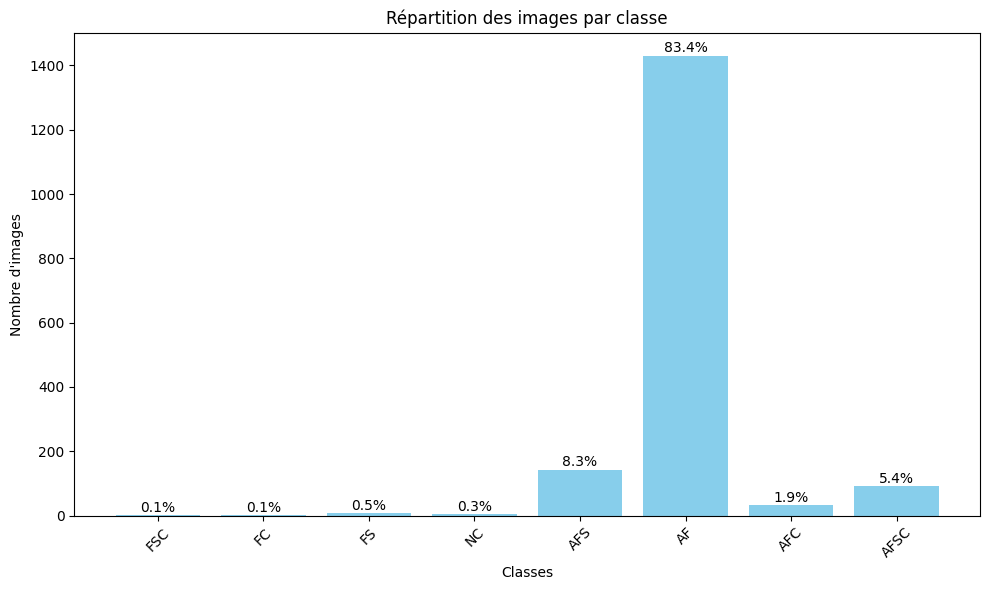

In [ ]:
print("Analyse de la distribution des classes...")
class_counts = plot_class_distribution(test_dir)

In [ ]:
vgg19.load_state_dict(torch.load("/content/drive/MyDrive/Dossier_de_Basse/split_best_vgg19.pth"))
vgg19.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = vgg19(imgs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total * 100
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 94.17%
